# PTI-Clima Notebooks  <img src="https://www.r-project.org/logo/Rlogo.png" alt="Description" width="60" height="40">

***

> Este cuaderno o notebook muestra LO QUE MUESTRE EL NOTEBOOK utilizando los conjuntos de datos de la PTI-Clima que se incluyen en el [almacén de datos](https://pti.climate.ifca.es/data). Este trabajo está licenciado bajo una [Licencia Creative Commons Atribución 4.0 Internacional](http://creativecommons.org/licenses/by/4.0).
>
> ![Licencia de Creative Commons](https://i.creativecommons.org/l/by/4.0/88x31.png)


## Inconsistencias encontradas en los datasets PTI-CLIMA-V0 y PTI-CLIMA-V1

**M. Fuente-González** (Instituto de Física de Cantabria, CSIC-Universidad de Cantabria, Santander, Spain).

En este cuaderno se quieren mostrar las inconsistencias encontradas en los datasets PTI-CLIMA-V0 y PTI-CLIMA-V1 en las variables de temperatura máxima y temperatura mínima. Se ha observado que existen gridboxes donde la temperatura mínima (tmin) es mayor que la temperatura máxima. A continuación, se adjunta lo obtenido tanto para las observaciones de Canarias como de la Península Ibérica.

In [1]:
options(java.parameters = "-Xmx3g")

### 1. Carga de librerías

In [2]:
library(loadeR)
library(transformeR)
library(visualizeR)

Loading required package: rJava

Loading required package: loadeR.java

Java version 22x amd64 by N/A detected

NetCDF Java Library v4.6.0-SNAPSHOT (23 Apr 2015) loaded and ready

Loading required package: climate4R.UDG

climate4R.UDG version 0.2.6 (2023-06-26) is loaded

Please use 'citation("climate4R.UDG")' to cite this package.

loadeR version 1.8.1 (2023-06-22) is loaded


Get the latest stable version (1.8.2) using <devtools::install_github(c('SantanderMetGroup/climate4R.UDG','SantanderMetGroup/loadeR'))>

Please use 'citation("loadeR")' to cite this package.




    _______   ____  ___________________  __  ________ 
   / ___/ /  / /  |/  / __  /_  __/ __/ / / / / __  / 
  / /  / /  / / /|_/ / /_/ / / / / __/ / /_/ / /_/_/  
 / /__/ /__/ / /  / / __  / / / / /__ /___  / / \ \ 
 \___/____/_/_/  /_/_/ /_/ /_/  \___/    /_/\/   \_\ 
 
      github.com/SantanderMetGroup/climate4R



transformeR version 2.2.2 (2023-10-26) is loaded


Get the latest stable version (2.2.3) using <devtools::install_github('SantanderMetGroup/transformeR')>

Please see 'citation("transformeR")' to cite this package.

visualizeR version 1.6.4 (2023-10-26) is loaded

Please see 'citation("visualizeR")' to cite this package.



In [3]:
df <- read.csv("../data_inventory.csv")

In [4]:
year.study <- 1976

### PTI-CLIMA-V0

In [5]:
subset(df, source == "PTI-grid-v0")

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
4,PTI-grid-v0_Canarias_day,observations,opendap,PTI-grid-v0,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v0/Canarias/day/PTI-grid-v0_Canarias_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic
5,PTI-grid-v0_Iberia_day,observations,opendap,PTI-grid-v0,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v0/Iberia/day/PTI-grid-v0_Iberia_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic


#### Península Ibérica

In [6]:
subset.pi <- subset(df, dataset == "PTI-grid-v0_Iberia_day")
lon.pi <- as.character(subset.pi$endpoint)

En este año en concreto se han visto estas inconsistencias, pero también las hay en otros años.

In [7]:
tasmax <- loadGridData(dataset = lon.pi,
                           var = "tmax",
                           years = year.study)

tasmin <- loadGridData(dataset = lon.pi,
                           var = "tmin",
                           years = year.study)

[2025-09-17 12:06:14.263647] Opening dataset...

[2025-09-17 12:06:15.273961] The dataset was successfuly opened

[2025-09-17 12:06:15.281568] Defining geo-location parameters

[2025-09-17 12:06:15.377814] Defining time selection parameters

[2025-09-17 12:06:15.57568] Retrieving data subset ...

[2025-09-17 12:06:42.059164] Done

[2025-09-17 12:06:42.203342] Opening dataset...

[2025-09-17 12:06:42.342635] The dataset was successfuly opened

[2025-09-17 12:06:42.346749] Defining geo-location parameters

[2025-09-17 12:06:42.412232] Defining time selection parameters

[2025-09-17 12:06:42.554691] Retrieving data subset ...

[2025-09-17 12:07:06.411946] Done



In [8]:
diff <- gridArithmetics(tasmin, tasmax, operator="-")

In [9]:
str(diff)

List of 4
 $ Variable:List of 2
  ..$ varName: chr "tmin"
  ..$ level  : NULL
  ..- attr(*, "use_dictionary")= logi FALSE
  ..- attr(*, "description")= chr "Minimum temperature"
  ..- attr(*, "units")= chr "grades celsius"
  ..- attr(*, "longname")= chr "tmin"
  ..- attr(*, "daily_agg_cellfun")= chr "none"
  ..- attr(*, "monthly_agg_cellfun")= chr "none"
  ..- attr(*, "verification_time")= chr "none"
 $ Data    : num [1:366, 1:341, 1:545] NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN ...
  ..- attr(*, "dimensions")= chr [1:3] "time" "lat" "lon"
 $ xyCoords:List of 2
  ..$ x: num [1:545] -9.29 -9.26 -9.24 -9.21 -9.19 ...
  ..$ y: num [1:341] 35.3 35.3 35.3 35.4 35.4 ...
  ..- attr(*, "projection")= chr "LatLonProjection"
  ..- attr(*, "resX")= num 0.025
  ..- attr(*, "resY")= num 0.025
 $ Dates   :List of 2
  ..$ start: chr [1:366] "1976-01-01 00:00:00 GMT" "1976-01-02 00:00:00 GMT" "1976-01-03 00:00:00 GMT" "1976-01-04 00:00:00 GMT" ...
  ..$ end  : chr [1:366] "1976-01-01 00:00:00 GMT" "197

In [10]:
summary(diff$Data)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max.     NA's 
     -28      -15      -12      -12       -9        2 37006992 

Esta diferencia donde la tmin > tmax, no supera los 2ºC. La celda siguiente, permite ver los valores de tmax, tmin y la diferencia de los gridboxes donde tmin > tmax.

In [11]:
indices <- which(diff$Data > 0, arr.ind = TRUE)

dif.temp <- data.frame(
  time = indices[,1],
  lat_idx = indices[,2],
  lon_idx = indices[,3],
  tasmax = tasmax$Data[indices],
  tasmin = tasmin$Data[indices],
  diff = diff$Data[indices]
)

print(dif.temp)

    time lat_idx lon_idx      tasmax       tasmin        diff
1    337     316      69  8.30209160  8.332069397 0.029977798
2    337     317      69  8.48585415  8.528632164 0.042778015
3    337     318      69  8.55462360  8.575653076 0.021029472
4    337     314      70  7.76707077  7.777445793 0.010375023
5    337     315      70  7.82274580  8.031245232 0.208499432
6    337     316      70  8.16352081  8.420145988 0.256625175
7    337     317      70  8.36597157  8.612451553 0.246479988
8    337     318      70  8.49479771  8.669962883 0.175165176
9    337     319      70  8.78147221  8.807679176 0.026206970
10   337     313      71  7.05786037  7.149971008 0.092110634
11   337     314      71  7.67943668  7.869909286 0.190472603
12   337     315      71  7.78643608  8.204185486 0.417749405
13   337     316      71  7.99804735  8.517760277 0.519712925
14   337     317      71  8.27591133  8.733043671 0.457132339
15   337     318      71  8.52398682  8.831922531 0.307935715
16   337

Para ver las zonas donde se produce la inconsistencia

In [12]:
diff$Data[diff$Data>0] <- 1
diff$Data[diff$Data<=0] <- 0

[2025-09-17 12:07:48.616661] - Computing climatology...

[2025-09-17 12:07:55.599676] - Done.



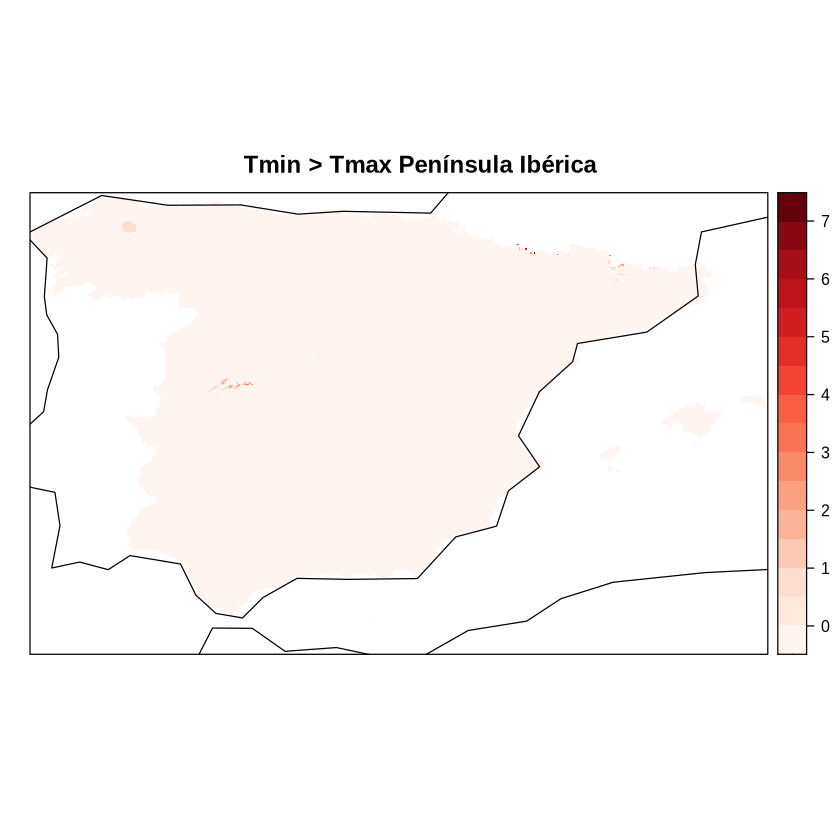

In [13]:
spatialPlot(climatology(diff, clim.fun = list(FUN = "sum", na.rm = FALSE)), backdrop.theme="coastline", main="Tmin > Tmax Península Ibérica", color.theme="Reds")

#### Canarias

In [14]:
subset.c <- subset(df, dataset == "PTI-grid-v0_Canarias_day")
lon.c <- as.character(subset.c$endpoint)

In [15]:
tasmax.c <- loadGridData(dataset = lon.c,
                           var = "tmax",
                           years = year.study)

tasmin.c <- loadGridData(dataset = lon.c,
                           var = "tmin",
                           years = year.study)

[2025-09-17 12:07:56.977338] Opening dataset...

[2025-09-17 12:07:57.101337] The dataset was successfuly opened

[2025-09-17 12:07:57.105834] Defining geo-location parameters

[2025-09-17 12:07:57.198677] Defining time selection parameters

[2025-09-17 12:07:57.333387] Retrieving data subset ...

[2025-09-17 12:07:58.77813] Done

[2025-09-17 12:07:58.943544] Opening dataset...

[2025-09-17 12:07:59.035903] The dataset was successfuly opened

[2025-09-17 12:07:59.040479] Defining geo-location parameters

[2025-09-17 12:07:59.166275] Defining time selection parameters

[2025-09-17 12:07:59.292542] Retrieving data subset ...

[2025-09-17 12:08:00.818026] Done



In [16]:
diff.c <- gridArithmetics(tasmin.c, tasmax.c, operator="-")

In [17]:
summary(diff.c$Data)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
    -25      -7      -5      -5      -4      16 4500336 

In [18]:
indices.c <- which(diff.c$Data > 0, arr.ind = TRUE)

dif.temp.c <- data.frame(
  time = indices.c[,1],
  lat_idx = indices.c[,2],
  lon_idx = indices.c[,3],
  tasmax = tasmax.c$Data[indices.c],
  tasmin = tasmin.c$Data[indices.c],
  diff = diff.c$Data[indices.c]
)

print(dif.temp.c)

     time lat_idx lon_idx       tasmax      tasmin         diff
1      26       3       2  12.20455742 12.38682652 1.822691e-01
2      27       3       2  10.88218212 12.12675571 1.244574e+00
3      35       3       2  10.93412304 11.75851536 8.243923e-01
4     304       3       2  17.35636520 17.60557175 2.492065e-01
5      26       4       2  10.50030613 11.52406883 1.023763e+00
6      27       4       2   8.76323128 11.53296185 2.769731e+00
7      35       4       2   9.11430454 10.83466148 1.720357e+00
8     304       4       2  15.76770687 16.84241867 1.074712e+00
9      26       3       3  10.59052849 12.32123852 1.730710e+00
10     27       3       3   9.27802372 12.53044224 3.252419e+00
11     35       3       3   8.75392056 11.59123993 2.837319e+00
12     46       3       3  10.02921677 10.52623844 4.970217e-01
13     63       3       3   9.37374973  9.73148632 3.577366e-01
14     83       3       3  12.29763699 12.62620831 3.285713e-01
15    128       3       3  10.36516285 1

In [19]:
diff.c$Data[diff.c$Data>0] <- 1
diff.c$Data[diff.c$Data<=0] <- 0

[2025-09-17 12:08:03.74135] - Computing climatology...

[2025-09-17 12:08:04.68479] - Done.



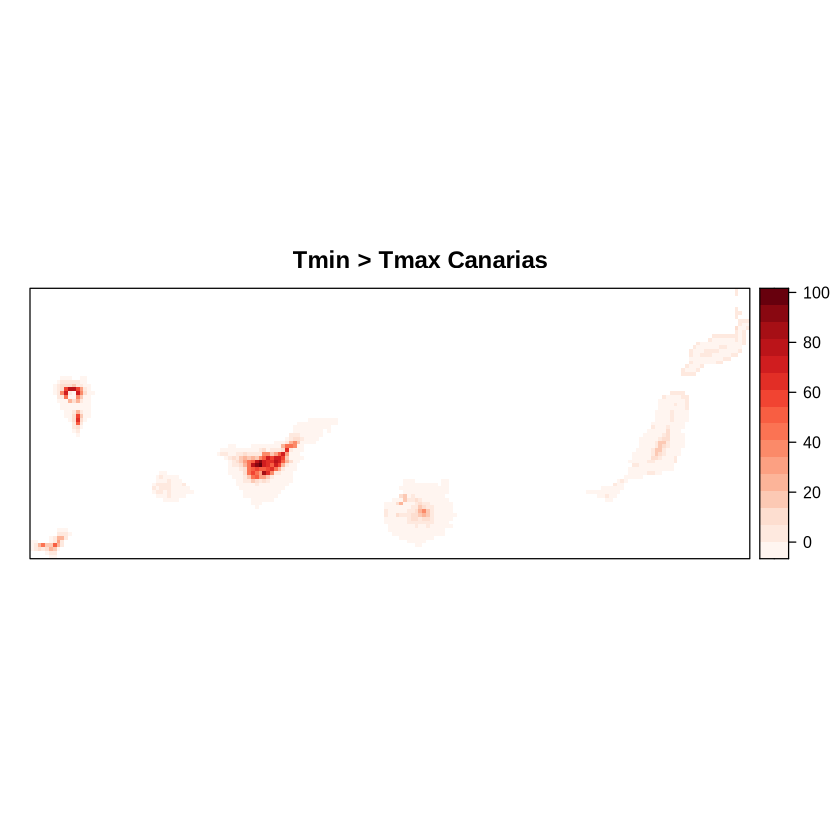

In [20]:
spatialPlot(climatology(diff.c, clim.fun = list(FUN = "sum", na.rm = FALSE)), backdrop.theme="coastline", main="Tmin > Tmax Canarias", color.theme="Reds")

### PTI-CLIMA-V1

In [21]:
subset(df, source == "PTI-grid-v1")

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
6,PTI-grid-v1_Canarias_day,observations,opendap,PTI-grid-v1,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v1/Canarias/day/PTI-grid-v1_Canarias_day.ncml,../../Harmonization_dictionaries/PTI-grid-v1.dic
7,PTI-grid-v1_Iberia_day,observations,opendap,PTI-grid-v1,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v1/Iberia/day/PTI-grid-v1_Iberia_day.ncml,../../Harmonization_dictionaries/PTI-grid-v1.dic


#### Península Ibérica

In [22]:
subset.pi.v1 <- subset(df, dataset == "PTI-grid-v1_Iberia_day")
lon.pi.v1 <- as.character(subset.pi.v1$endpoint)

In [23]:
tasmax.v1 <- loadGridData(dataset = lon.pi.v1,
                           var = "tmax",
                           years = year.study)

tasmin.v1 <- loadGridData(dataset = lon.pi.v1,
                           var = "tmin",
                           years = year.study)

[2025-09-17 12:08:05.273901] Opening dataset...

[2025-09-17 12:08:05.396045] The dataset was successfuly opened

[2025-09-17 12:08:05.400641] Defining geo-location parameters

[2025-09-17 12:08:05.466459] Defining time selection parameters

[2025-09-17 12:08:05.60289] Retrieving data subset ...

[2025-09-17 12:08:29.396249] Done

[2025-09-17 12:08:29.565638] Opening dataset...

[2025-09-17 12:08:29.708201] The dataset was successfuly opened

[2025-09-17 12:08:29.712614] Defining geo-location parameters

[2025-09-17 12:08:29.779121] Defining time selection parameters

[2025-09-17 12:08:29.906321] Retrieving data subset ...

[2025-09-17 12:08:51.78099] Done



In [24]:
diff.v1 <- gridArithmetics(tasmin.v1, tasmax.v1, operator="-")

In [25]:
summary(diff.v1$Data)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max.     NA's 
     -30      -14      -11      -11       -8        8 37206462 

In [26]:
indices.v1 <- which(diff.v1$Data > 0, arr.ind = TRUE)

dif.temp.v1 <- data.frame(
  time = indices.v1[,1],
  lat_idx = indices.v1[,2],
  lon_idx = indices.v1[,3],
  tasmax = tasmax.v1$Data[indices.v1],
  tasmin = tasmin.v1$Data[indices.v1],
  diff = diff.v1$Data[indices.v1]
)

print(dif.temp.v1)

      time lat_idx lon_idx        tasmax        tasmin         diff
1      352     262      48  3.890305e+00  4.064423e+00 0.1741180420
2      113     262      49  5.055483e+00  5.801273e+00 0.7457904816
3      339     262      49  8.194286e-01  8.639945e-01 0.0445659161
4      344     262      49  4.581670e+00  4.819110e+00 0.2374401093
5      348     262      49  2.255032e+00  4.418278e+00 2.1632459164
6      350     262      49  2.197978e+00  2.441300e+00 0.2433218956
7      351     262      49  3.833972e+00  4.232004e+00 0.3980317116
8      352     262      49  2.027087e+00  3.517868e+00 1.4907805920
9      352     270      49  2.866959e+00  3.013111e+00 0.1461522579
10      94     337      54  5.655822e+00  5.667602e+00 0.0117797852
11      94     338      55  5.585452e+00  5.665082e+00 0.0796303749
12     355     277      74  6.150633e-01  7.368783e-01 0.1218150258
13      31     278      76  9.545797e-03  1.442734e-01 0.1347275879
14     352     278      76  2.466216e+00  2.5717

In [27]:
diff.v1$Data[diff.v1$Data>0] <- 1
diff.v1$Data[diff.v1$Data<=0] <- 0

[2025-09-17 12:09:35.274273] - Computing climatology...

[2025-09-17 12:09:41.57484] - Done.



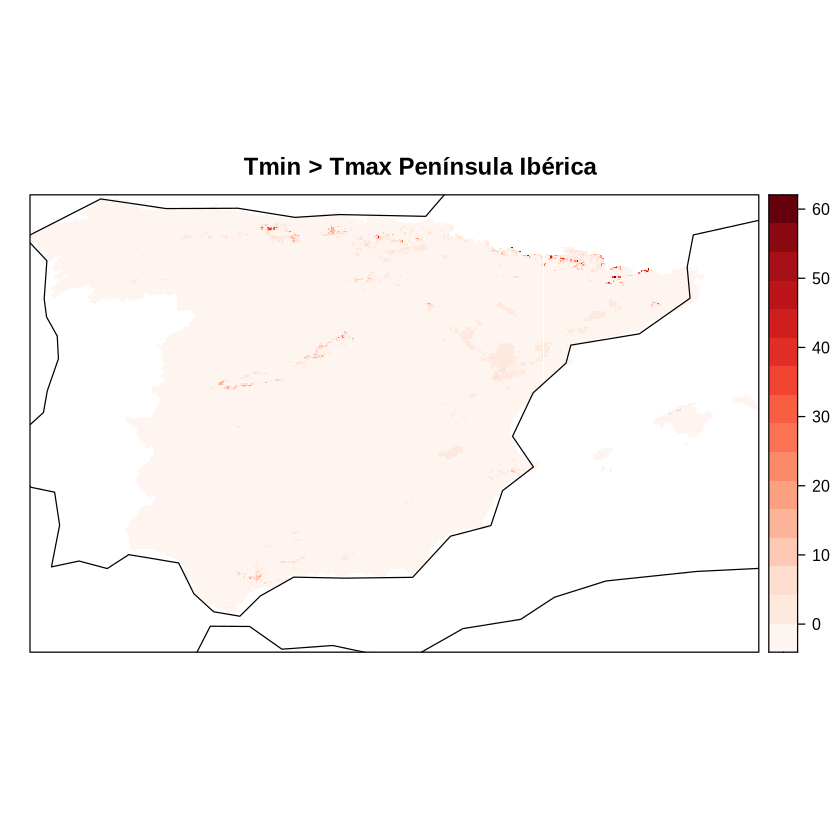

In [28]:
spatialPlot(climatology(diff.v1, clim.fun = list(FUN = "sum", na.rm = FALSE)), backdrop.theme="coastline", main="Tmin > Tmax Península Ibérica", color.theme="Reds")

#### Canarias

In [29]:
subset.c.v1 <- subset(df, dataset == "PTI-grid-v1_Canarias_day")
lon.c.v1 <- as.character(subset.c.v1$endpoint)

In [30]:
tasmax.c.v1 <- loadGridData(dataset = lon.c.v1,
                           var = "tmax",
                           years = year.study)

tasmin.c.v1 <- loadGridData(dataset = lon.c.v1,
                           var = "tmin",
                           years = year.study)

[2025-09-17 12:09:43.35654] Opening dataset...

[2025-09-17 12:09:43.486706] The dataset was successfuly opened

[2025-09-17 12:09:43.49202] Defining geo-location parameters

[2025-09-17 12:09:43.551835] Defining time selection parameters

[2025-09-17 12:09:43.687516] Retrieving data subset ...

[2025-09-17 12:09:44.99821] Done

[2025-09-17 12:09:45.139004] Opening dataset...

[2025-09-17 12:09:45.22504] The dataset was successfuly opened

[2025-09-17 12:09:45.230506] Defining geo-location parameters

[2025-09-17 12:09:45.357874] Defining time selection parameters

[2025-09-17 12:09:45.477125] Retrieving data subset ...

[2025-09-17 12:09:46.723638] Done



In [31]:
diff.c.v1 <- gridArithmetics(tasmin.c.v1, tasmax.c.v1, operator="-")

In [32]:
summary(diff.c.v1$Data)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
    -37      -6      -2      -2       2      38 4544256 

In [33]:
indices.v1.c <- which(diff.c.v1$Data > 0, arr.ind = TRUE)

dif.temp.v1.c <- data.frame(
  time = indices.v1.c[,1],
  lat_idx = indices.v1.c[,2],
  lon_idx = indices.v1.c[,3],
  tasmax = tasmax.c.v1$Data[indices.v1.c],
  tasmin = tasmin.c.v1$Data[indices.v1.c],
  diff = diff.c.v1$Data[indices.v1.c]
)

print(dif.temp.v1.c)

      time lat_idx lon_idx       tasmax        tasmin         diff
1       26       3       1  11.67113018  1.211360e+01 4.424725e-01
2       35       3       1   8.99675274  1.323845e+01 4.241702e+00
3       39       3       1  13.71996880  1.426307e+01 5.430984e-01
4       49       3       1  10.51354122  1.236044e+01 1.846897e+00
5       52       3       1  12.85815048  1.307250e+01 2.143488e-01
6       80       3       1   9.54141903  1.324885e+01 3.707436e+00
7       87       3       1  12.44849491  1.576071e+01 3.312217e+00
8       90       3       1  10.78756428  1.540965e+01 4.622089e+00
9       92       3       1  10.01765156  1.361662e+01 3.598970e+00
10      93       3       1   9.34013081  1.216969e+01 2.829562e+00
11      94       3       1   9.64424324  1.440337e+01 4.759131e+00
12      97       3       1  12.12044525  1.446828e+01 2.347837e+00
13      99       3       1  11.77619648  1.250228e+01 7.260838e-01
14     101       3       1  10.86802959  1.659404e+01 5.726008

In [34]:
diff.c.v1$Data[diff.c.v1$Data>0] <- 1
diff.c.v1$Data[diff.c.v1$Data<=0] <- 0

[2025-09-17 12:09:50.19958] - Computing climatology...

[2025-09-17 12:09:50.911297] - Done.



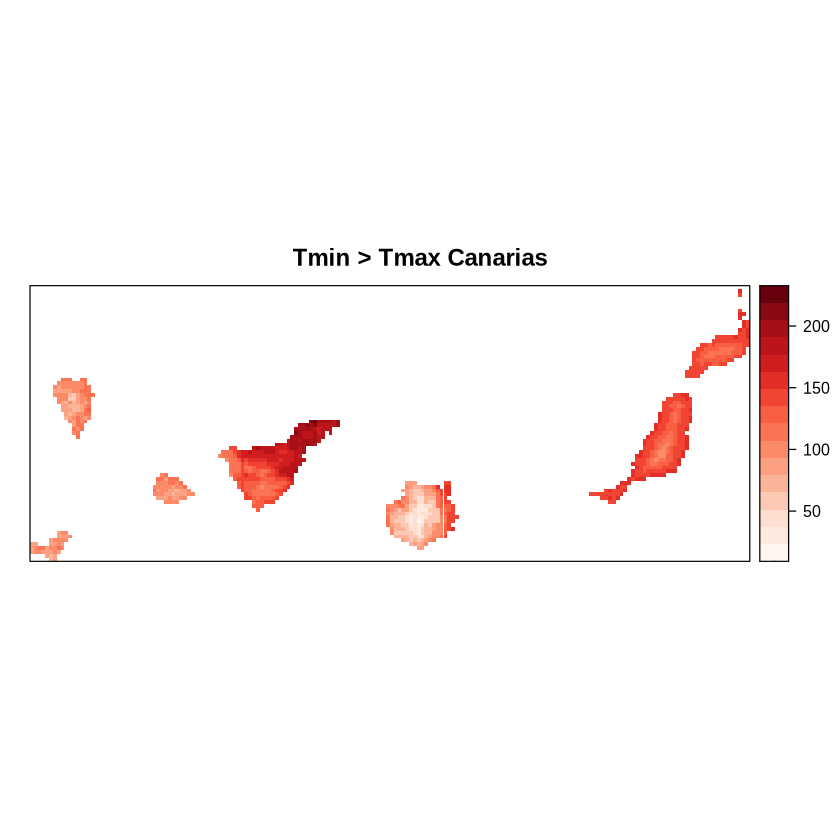

In [35]:
spatialPlot(climatology(diff.c.v1, clim.fun = list(FUN = "sum", na.rm = FALSE)), backdrop.theme="coastline", main="Tmin > Tmax Canarias", color.theme="Reds")